<a href="https://colab.research.google.com/github/BiswarupMukherjee1/spacecraft-pose-failure-detection/blob/main/Exp1_2_3_pose_estimation_benchmarking_confidence_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A benchmark of classical and learned keypoint detectors for spacecraft pose estimation, with confidence calibration

Biswarup Mukherjee

For close-range visual navigation, a wrong pose returned with high confidence is more dangerous than one flagged as uncertain. A confident wrong pose propagates into the Guidance, Navigation and Control (GNC) loop, while an uncertain one can be rejected, retried, or fused with another sensor. So a detector should be judged not only on accuracy, but on whether it can tell, at runtime and without ground truth, when its own estimate is wrong.

This notebook studies that question:

> *Given that the system produced a pose, can it tell us whether to trust it, without access to ground truth?*

## What the notebook does

1. Benchmark three keypoint detectors on relative pose accuracy. Each runs through the same chain: keypoint detection → matching to a known 3D model → PnP (Perspective-n-Point) + RANSAC.
   - **ORB** : classical, FAST + BRIEF binary descriptor (cv2)
   - **SIFT** : classical, scale-invariant blob detector + float descriptor (cv2)
   - **DISK** : pretrained CNN keypoint detector and descriptor (Tyszkiewicz et al., NeurIPS 2020; loaded via Kornia)
2. Sweep four image degradations (motion blur, brightness, additive noise, partial occlusion) over six severity levels. For every run, record the actual pose error and three confidence signals that need no ground truth.
3. For each signal, ROC curves measure whether it predicts failure, and reliability diagrams with Expected Calibration Error (ECE) measure whether it is well calibrated.

## Scope

The target is a programmatic spacecraft-like wireframe, with exact 3D ground truth and exact 2D projections. Failure thresholds (translation < 1 m, rotation < 10°) are chosen for the study, not derived from a mission specification. The point is the method: a detector is judged by how it behaves as the image degrades and by whether it knows when it has failed, not by a single error number on a clean image.

In [ ]:
# Dependencies. kornia gives DISK.
!pip install -q opencv-contrib-python kornia 2>&1 | tail -3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 53.1 MB/s eta 0:00:00


In [ ]:
import os, time, warnings, math
from typing import List, Tuple, Optional, Dict
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"OpenCV: {cv2.__version__}  |  PyTorch: {torch.__version__}  |  Device: {device}")
import kornia
print(f"Kornia: {kornia.__version__}")
import kornia.feature as KF

OpenCV: 4.13.0  |  PyTorch: 2.11.0+cu128  |  Device: cuda
Kornia: 0.8.3


## 1. Synthetic target (experiment data)

A programmatic spacecraft: cuboid body (1 m × 1 m × 1.5 m) + two thin solar panels. Sixteen keypoints at known 3D coordinates in the body frame.

A programmatic target keeps the experiment exact ground-truth pose and ground-truth 2D projections are known to numerical precision. The pipeline architecture transfers to a real spacecraft with a known CAD model.

In [ ]:
def build_spacecraft_keypoints() -> np.ndarray:
    body = np.array([
        [-0.5,-0.5,-0.75],[ 0.5,-0.5,-0.75],[ 0.5, 0.5,-0.75],[-0.5, 0.5,-0.75],
        [-0.5,-0.5, 0.75],[ 0.5,-0.5, 0.75],[ 0.5, 0.5, 0.75],[-0.5, 0.5, 0.75],
    ])
    left_panel  = np.array([[-2.5,-0.02,-0.5],[-0.5,-0.02,-0.5],[-0.5,-0.02, 0.5],[-2.5,-0.02, 0.5]])
    right_panel = np.array([[ 0.5, 0.02,-0.5],[ 2.5, 0.02,-0.5],[ 2.5, 0.02, 0.5],[ 0.5, 0.02, 0.5]])
    return np.vstack([body, left_panel, right_panel]).astype(np.float32)

SPACECRAFT_EDGES = [
    (0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),
    (0,4),(1,5),(2,6),(3,7),
    (8,9),(9,10),(10,11),(11,8),
    (12,13),(13,14),(14,15),(15,12),
]
SPACECRAFT_FACES = [
    ([0,1,2,3],(120,130,150)),([4,5,6,7],(160,170,190)),
    ([0,1,5,4],(140,150,170)),([2,3,7,6],(140,150,170)),
    ([1,2,6,5],(130,140,160)),([0,3,7,4],(130,140,160)),
    ([8,9,10,11],(40,50,110)),([12,13,14,15],(40,50,110)),
]
SPACECRAFT_3D = build_spacecraft_keypoints()
print(f"Spacecraft model: {SPACECRAFT_3D.shape[0]} keypoints; "
      f"X-span {SPACECRAFT_3D[:,0].max()-SPACECRAFT_3D[:,0].min():.2f} m")

Spacecraft model: 16 keypoints; X-span 5.00 m


## 2. Camera, projection, rendering

Pinhole camera, 640 × 480, fx = fy = 800 px. Poses sampled in a proximity-operations regime: target distance 5–15 m, rotation ±30° per axis, lateral offsets ±0.5 m.

In [ ]:
IMG_W, IMG_H = 640, 480
FX = FY = 800.0
CX, CY = IMG_W/2., IMG_H/2.
CAMERA_K = np.array([[FX,0,CX],[0,FY,CY],[0,0,1.]], dtype=np.float64)
CAMERA_DIST = np.zeros(5, dtype=np.float64)

def random_pose(rng, z_range=(5.,15.), xy_range=0.5, rot_range_deg=30.):
    a = rng.uniform(-rot_range_deg, rot_range_deg, 3) * np.pi/180.
    Rx = cv2.Rodrigues(np.array([a[0],0,0]))[0]
    Ry = cv2.Rodrigues(np.array([0,a[1],0]))[0]
    Rz = cv2.Rodrigues(np.array([0,0,a[2]]))[0]
    R = Rz @ Ry @ Rx
    rvec, _ = cv2.Rodrigues(R)
    tvec = np.array([rng.uniform(-xy_range,xy_range),
                     rng.uniform(-xy_range,xy_range),
                     rng.uniform(*z_range)])
    return rvec.flatten(), tvec

def project_points(P3, rvec, tvec):
    p, _ = cv2.projectPoints(P3.astype(np.float64), rvec.astype(np.float64),
                             tvec.astype(np.float64), CAMERA_K, CAMERA_DIST)
    return p.reshape(-1,2)

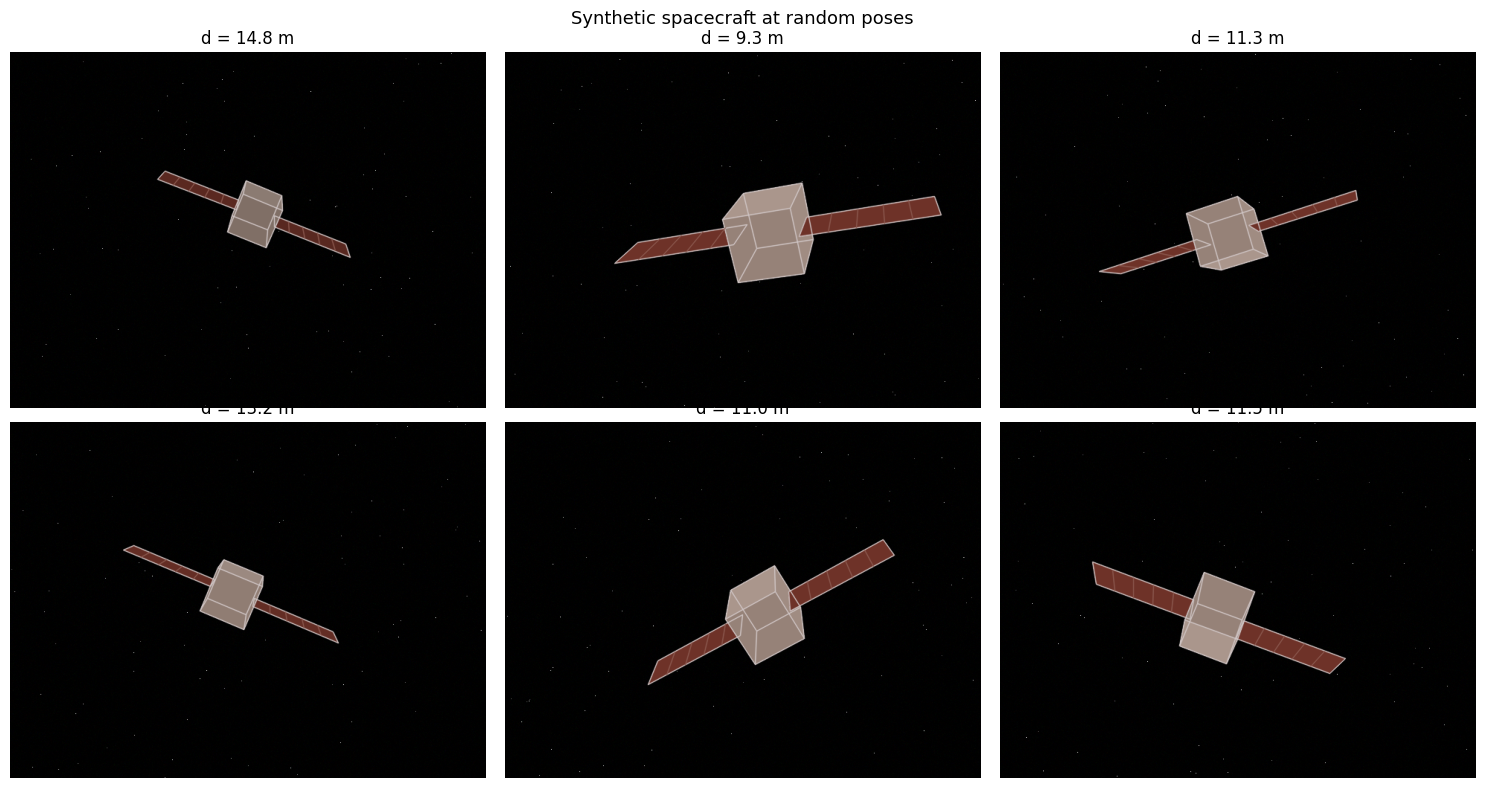

In [ ]:
def render_image(rvec, tvec, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    img = np.zeros((IMG_H, IMG_W, 3), np.uint8)
    n = 80
    sx = rng.integers(0, IMG_W, n); sy = rng.integers(0, IMG_H, n)
    sb = rng.integers(80, 255, n)
    for i in range(n):
        cv2.circle(img, (int(sx[i]),int(sy[i])), 0, (int(sb[i]),)*3, -1)
    img = cv2.add(img, rng.normal(0,3,img.shape).clip(0,30).astype(np.uint8))
    R = cv2.Rodrigues(rvec)[0]
    pts_cam = (R @ SPACECRAFT_3D.T).T + tvec.reshape(1,3)
    pts_2d = project_points(SPACECRAFT_3D, rvec, tvec)
    faces = []
    for vidx, color in SPACECRAFT_FACES:
        d = pts_cam[vidx,2].mean()
        if d < 0.5: continue
        faces.append((d, vidx, color))
    faces.sort(key=lambda x: -x[0])
    for d, vidx, color in faces:
        poly = pts_2d[vidx].astype(np.int32)
        if (poly[:,0].max()<0 or poly[:,0].min()>IMG_W or
            poly[:,1].max()<0 or poly[:,1].min()>IMG_H): continue
        shade = max(0.5, min(1.0, 12.0/max(d,4.0)))
        cv2.fillPoly(img, [poly], tuple(int(c*shade) for c in color))
    for i,j in SPACECRAFT_EDGES:
        p1, p2 = pts_2d[i], pts_2d[j]
        if (-100<p1[0]<IMG_W+100 and -100<p1[1]<IMG_H+100 and
            -100<p2[0]<IMG_W+100 and -100<p2[1]<IMG_H+100):
            cv2.line(img, tuple(p1.astype(int)), tuple(p2.astype(int)),
                     (200,200,210), 1, cv2.LINE_AA)
    for panel_idx in [(8,9,10,11),(12,13,14,15)]:
        p = pts_2d[list(panel_idx)].astype(np.float32)
        for t in np.linspace(0.2, 0.8, 4):
            a = (1-t)*p[0] + t*p[1]; b = (1-t)*p[3] + t*p[2]
            cv2.line(img, tuple(a.astype(int)), tuple(b.astype(int)),
                     (80,90,140), 1, cv2.LINE_AA)
    return img

# Visualise
rng_d = np.random.default_rng(42)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax in axes.flat:
    rv, tv = random_pose(rng_d)
    img = render_image(rv, tv, rng=rng_d)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"d = {tv[2]:.1f} m"); ax.axis("off")
plt.suptitle("Synthetic spacecraft at random poses", fontsize=13)
plt.tight_layout(); plt.show()

## 3. Generate test set

In [ ]:
def generate_dataset(n, seed=0):
    rng = np.random.default_rng(seed)
    images, poses, kp2d = [], [], []
    for _ in range(n):
        rv, tv = random_pose(rng)
        images.append(render_image(rv, tv, rng=rng))
        poses.append((rv, tv))
        kp2d.append(project_points(SPACECRAFT_3D, rv, tv))
    return images, poses, kp2d

N_TEST = 40
test_images, test_poses, test_kp2d = generate_dataset(N_TEST, seed=123)
print(f"Generated {len(test_images)} test images.")

Generated 40 test images.


## 4. Three keypoint detectors

- **ORB** — classical, FAST keypoint detector + BRIEF binary descriptor. Fast, edge/corner based.
- **SIFT** — classical, scale-invariant blob detector + float descriptor (Lowe 2004). Slower, more robust to scale and rotation.
- **DISK** — *Discrete Keypoints*, a CNN-based learned detector and descriptor (Tyszkiewicz et al., NeurIPS 2020). Loaded pretrained via Kornia.

All three feed the same downstream stage: nearest-neighbour association of each detection to the nearest known model keypoint within a tolerance radius, then PnP+RANSAC. This isolates **detector quality** while keeping the downstream identical.

In [ ]:
# Initialise classical detectors
orb_det = cv2.ORB_create(nfeatures=1000, scaleFactor=1.2, nlevels=8)
sift_det = cv2.SIFT_create(nfeatures=1000, contrastThreshold=0.004, edgeThreshold=20)

# Load DISK (CNN, pretrained)
disk_model = KF.DISK.from_pretrained("depth").eval().to(device)
print(f"DISK loaded: {sum(p.numel() for p in disk_model.parameters()):,} parameters, on {device}")

Downloading: "https://raw.githubusercontent.com/cvlab-epfl/disk/master/depth-save.pth" to /root/.cache/torch/hub/checkpoints/depth-save.pth


100%|██████████| 4.17M/4.17M [00:00<00:00, 92.0MB/s]


DISK loaded: 1,092,369 parameters, on cuda


In [ ]:
def detect_classical(image_bgr, detector):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    kp = detector.detect(gray, None)
    if len(kp) == 0:
        return np.empty((0,2))
    return np.array([k.pt for k in kp])

def detect_disk(image_bgr, n_max=1024, score_thresh=0.5):
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(rgb).permute(2,0,1).unsqueeze(0).float().to(device) / 255.
    # DISK requires H,W divisible by 16; pad if needed
    H, W = t.shape[-2:]
    Hp = (H + 15) // 16 * 16
    Wp = (W + 15) // 16 * 16
    if (Hp, Wp) != (H, W):
        pad = (0, Wp - W, 0, Hp - H)
        t = torch.nn.functional.pad(t, pad)
    with torch.no_grad():
        feats = disk_model(t, n=n_max, score_threshold=score_thresh)
    kp = feats[0].keypoints.cpu().numpy()  # (N, 2) in (x, y)
    # Keep only inside the original frame
    mask = (kp[:,0] < W) & (kp[:,1] < H)
    return kp[mask]

def match_to_model(detected_2d, gt_kp_2d, radius=8.0):
    # Nearest-neighbour association: for each ground-truth projection, find the
    # nearest detection within `radius` px. Returns matched (3D, 2D) pairs.
    if len(detected_2d) == 0:
        return np.empty((0,3)), np.empty((0,2))
    m3d, m2d = [], []
    for i, gt in enumerate(gt_kp_2d):
        if not (0 <= gt[0] < IMG_W and 0 <= gt[1] < IMG_H):
            continue
        d = np.linalg.norm(detected_2d - gt, axis=1)
        b = int(np.argmin(d))
        if d[b] < radius:
            m3d.append(SPACECRAFT_3D[i])
            m2d.append(detected_2d[b])
    if m3d:
        return np.array(m3d), np.array(m2d)
    return np.empty((0,3)), np.empty((0,2))

# Quick sanity check on one image
img0 = test_images[0]
for name, fn in [("ORB",  lambda im: detect_classical(im, orb_det)),
                 ("SIFT", lambda im: detect_classical(im, sift_det)),
                 ("DISK", detect_disk)]:
    dets = fn(img0)
    m3, m2 = match_to_model(dets, test_kp2d[0])
    print(f"{name:5s}: {len(dets):4d} detections, {len(m3):2d}/16 matched to model")

ORB  :  585 detections, 16/16 matched to model
SIFT :   44 detections,  7/16 matched to model
DISK : 1024 detections,  9/16 matched to model


## 5. Pose recovery + confidence signals

The pipeline takes matched (3D model, 2D detection) correspondences and runs **cv2.solvePnPRansac**. From the result we record three **observables that do not require ground truth** , these are the candidate confidence signals:

- **N_inliers** — how many correspondences RANSAC marked as consistent with a single pose
- **inlier_ratio** — N_inliers / N_correspondences
- **inlier_reproj_err** — mean reprojection error over the inliers, in pixels (how well the recovered pose fits the data the pipeline itself trusts)

In [ ]:
def pose_error(rv_e, tv_e, rv_g, tv_g):
    t = float(np.linalg.norm(tv_e.flatten() - tv_g.flatten()))
    Re = cv2.Rodrigues(rv_e)[0]; Rg = cv2.Rodrigues(rv_g)[0]
    c = (np.trace(Re @ Rg.T) - 1.0) / 2.0
    c = float(np.clip(c, -1, 1))
    return t, float(np.degrees(np.arccos(c)))

def pose_pipeline(pts_3d, pts_2d):
    # Returns dict with rvec/tvec/n_inliers/inlier_ratio/inlier_reproj_err, or None values on failure.
    out = {"rvec": None, "tvec": None, "n_inliers": 0,
           "inlier_ratio": 0.0, "inlier_reproj_err": float("inf"),
           "n_matches": len(pts_3d)}
    if len(pts_3d) < 6:
        return out
    try:
        ok, rvec, tvec, inliers = cv2.solvePnPRansac(
            pts_3d.astype(np.float64), pts_2d.astype(np.float64),
            CAMERA_K, CAMERA_DIST,
            iterationsCount=200, reprojectionError=3.0,
            confidence=0.99, flags=cv2.SOLVEPNP_EPNP)
    except cv2.error:
        return out
    if not ok or inliers is None or len(inliers) < 4:
        return out
    inliers = inliers.flatten()
    out["rvec"] = rvec.flatten(); out["tvec"] = tvec.flatten()
    out["n_inliers"] = int(len(inliers))
    out["inlier_ratio"] = float(len(inliers) / len(pts_3d))
    # Mean reprojection error on the inliers
    proj, _ = cv2.projectPoints(pts_3d[inliers].astype(np.float64),
                                rvec, tvec, CAMERA_K, CAMERA_DIST)
    diff = proj.reshape(-1,2) - pts_2d[inliers]
    out["inlier_reproj_err"] = float(np.linalg.norm(diff, axis=1).mean())
    return out

# Sanity check on first image
for name, fn in [("ORB",  lambda im: detect_classical(im, orb_det)),
                 ("SIFT", lambda im: detect_classical(im, sift_det)),
                 ("DISK", detect_disk)]:
    dets = fn(test_images[0])
    m3, m2 = match_to_model(dets, test_kp2d[0])
    r = pose_pipeline(m3, m2)
    if r["rvec"] is None:
        print(f"{name}: pipeline FAILED")
    else:
        t_err, r_err = pose_error(r["rvec"], r["tvec"], *test_poses[0])
        print(f"{name:5s}: n_match={r['n_matches']:2d} n_inl={r['n_inliers']:2d} "
              f"inl_reproj={r['inlier_reproj_err']:.2f}px  "
              f"t_err={t_err:.3f}m  r_err={r_err:.2f}°")

ORB  : n_match=16 n_inl=16 inl_reproj=0.91px  t_err=0.092m  r_err=0.77°
SIFT : n_match= 7 n_inl= 6 inl_reproj=1.60px  t_err=0.176m  r_err=4.57°
DISK : n_match= 9 n_inl= 8 inl_reproj=1.59px  t_err=0.232m  r_err=0.50°


On a clean image all three pipelines recover pose, but the detector quality propagates directly into the geometric solver. ORB matches all 16 model keypoints with a 0.91 px reprojection residual and the lowest translation error (9 cm). SIFT matches only 7/16 and is worst on both axes. DISK matches 9/16, the extra ~1000 raw detections it produces are mostly off-keypoint clutter. But the inliers it does keep are geometrically clean enough to give the lowest rotation error of the three (0.50°).

The detector, not the geometry, is used further for the rest experiments.

## 6. Image degradations

Four parametric degradations are applied at increasing severity:

- **Motion blur**: linear horizontal blur kernel
- **Brightness**: multiplicative scaling
- **Gaussian noise**: additive zero-mean noise
- **Occlusion**: black square covering an increasing area fraction

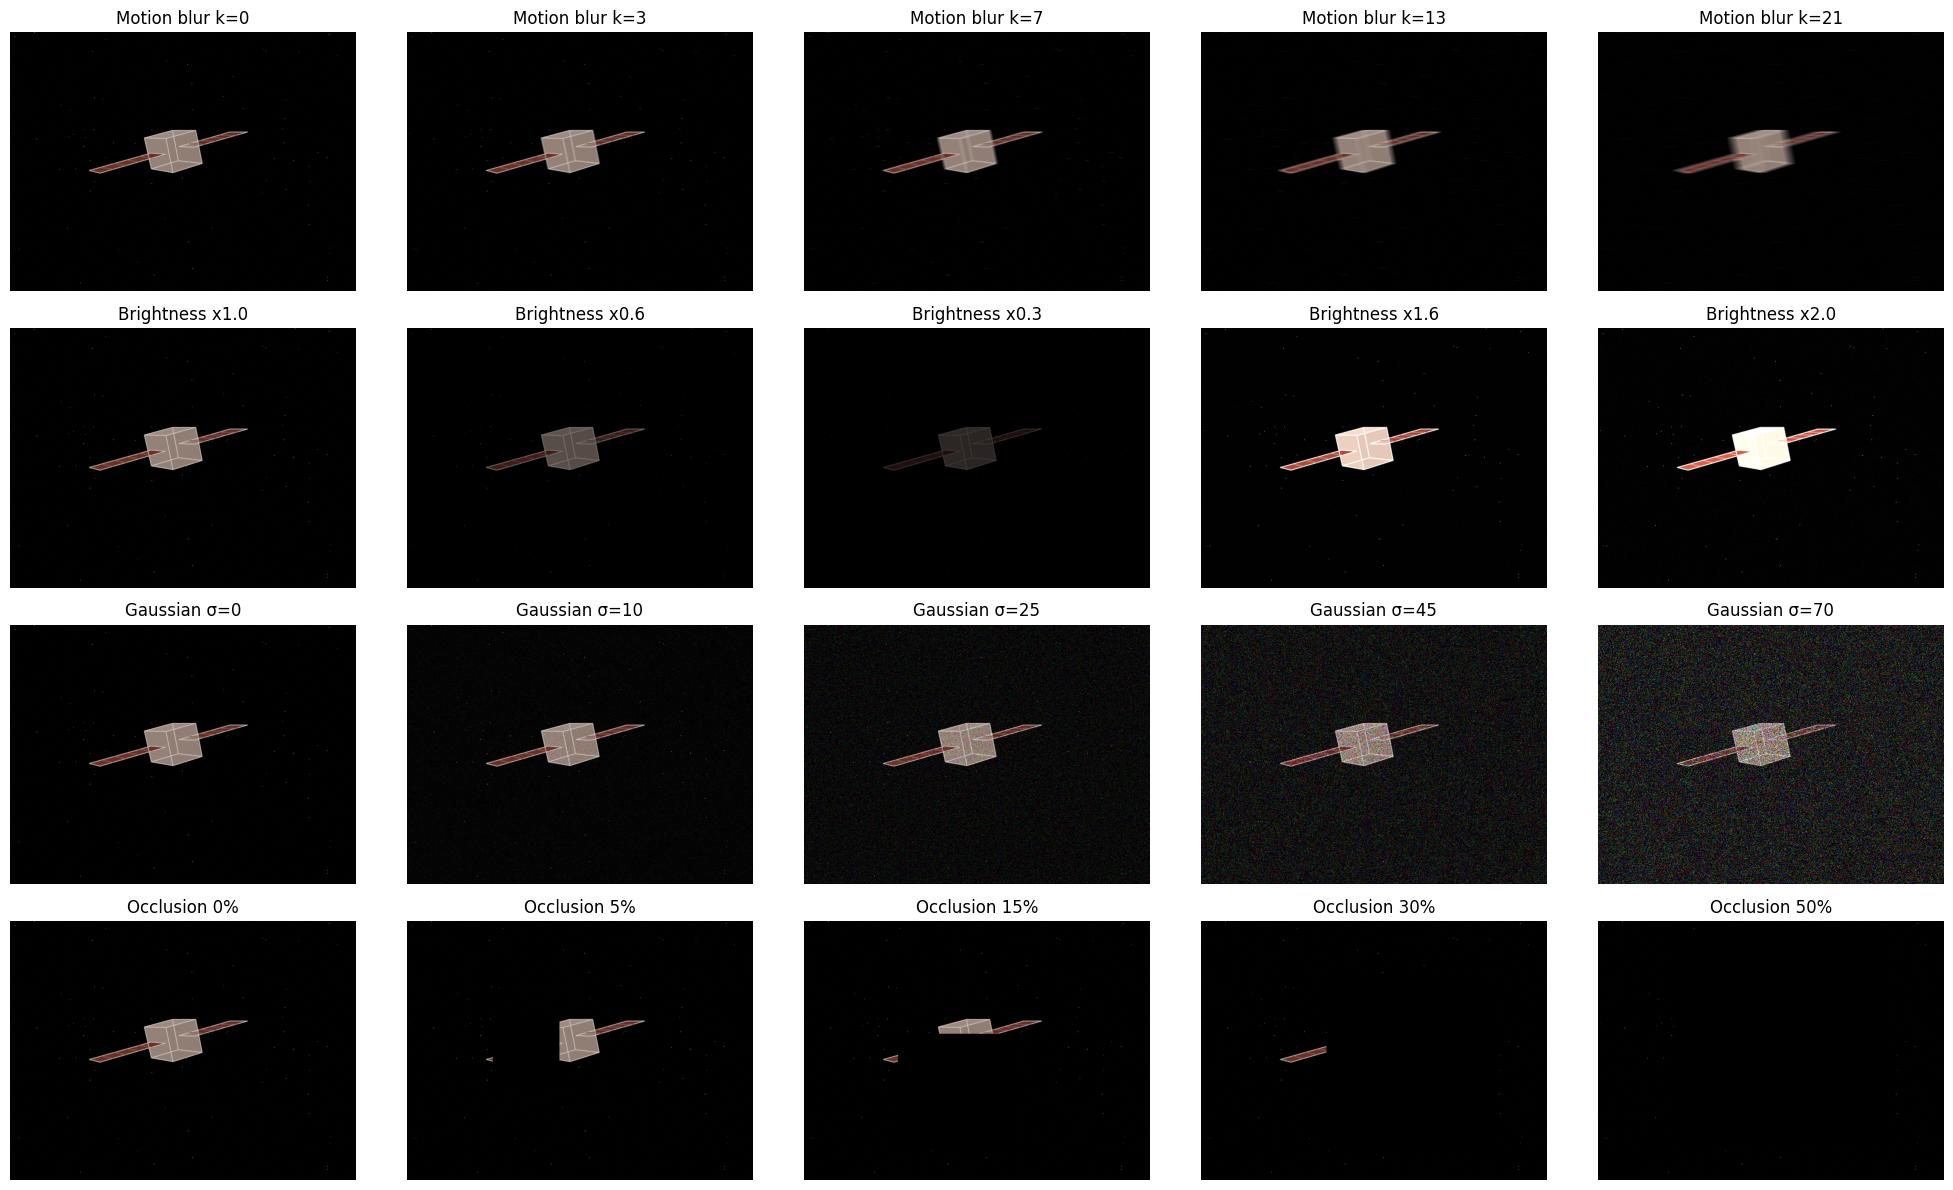

In [ ]:
def apply_motion_blur(img, k):
    if k == 0: return img.copy()
    ker = np.zeros((k, k), np.float32); ker[k//2, :] = 1.0/k
    return cv2.filter2D(img, -1, ker)

def apply_brightness(img, f):
    return np.clip(img.astype(np.float32) * f, 0, 255).astype(np.uint8)

def apply_gaussian_noise(img, sigma, rng):
    if sigma == 0: return img.copy()
    return np.clip(img.astype(np.float32) + rng.normal(0, sigma, img.shape),
                   0, 255).astype(np.uint8)

def apply_occlusion(img, fraction, rng):
    if fraction == 0: return img.copy()
    out = img.copy()
    side = int(np.sqrt(IMG_H * IMG_W * fraction))
    side = min(side, min(IMG_H, IMG_W) - 10)
    y0 = int(rng.integers(0, max(1, IMG_H - side)))
    x0 = int(rng.integers(0, max(1, IMG_W - side)))
    out[y0:y0+side, x0:x0+side] = 0
    return out

rng_v = np.random.default_rng(7)
fig, axes = plt.subplots(4, 5, figsize=(20, 12))
base = test_images[0]
specs = [
    ("Motion blur k=", apply_motion_blur,  [0, 3, 7, 13, 21],          False),
    ("Brightness x",   apply_brightness,   [1.0, 0.6, 0.3, 1.6, 2.0],  False),
    ("Gaussian σ=",    apply_gaussian_noise,[0, 10, 25, 45, 70],       True),
    ("Occlusion ",     apply_occlusion,    [0.0, 0.05, 0.15, 0.3, 0.5],True),
]
for r, (name, fn, lv, needs_rng) in enumerate(specs):
    for c, val in enumerate(lv):
        im = fn(base, val, rng_v) if needs_rng else fn(base, val)
        axes[r, c].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        if "Occlusion" in name:
            axes[r, c].set_title(f"{name}{val:.0%}")
        elif "Brightness" in name:
            axes[r, c].set_title(f"{name}{val:.1f}")
        else:
            axes[r, c].set_title(f"{name}{val}")
        axes[r, c].axis("off")
plt.tight_layout(); plt.show()

## 7. The sweep: every detector × every degradation × every severity

For every combination, record actual pose error and the confidence signals.

In [ ]:
import pandas as pd

DETECTORS = {
    "ORB":  lambda im: detect_classical(im, orb_det),
    "SIFT": lambda im: detect_classical(im, sift_det),
    "DISK": detect_disk,
}
SWEEPS = [
    ("motion_blur",      apply_motion_blur,    [0, 3, 7, 11, 17, 23],          False),
    ("brightness",       apply_brightness,     [1.0, 0.7, 0.5, 0.3, 1.5, 1.9], False),
    ("gaussian_noise",   apply_gaussian_noise, [0, 10, 25, 45, 65, 90],        True),
    ("occlusion",        apply_occlusion,      [0.0, 0.05, 0.15, 0.25, 0.4, 0.55], True),
]

rng_sweep = np.random.default_rng(SEED)
records = []
t_start = time.perf_counter()

for sweep_name, fn, levels, needs_rng in SWEEPS:
    for lvl in levels:
        # Pre-compute degraded images for this level (one rng draw per image keeps it deterministic across detectors)
        rng_lvl = np.random.default_rng(hash((sweep_name, str(lvl))) % (2**32))
        if needs_rng:
            degraded = [fn(img, lvl, rng_lvl) for img in test_images]
        else:
            degraded = [fn(img, lvl) for img in test_images]
        for det_name, det_fn in DETECTORS.items():
            for i, (img, pose_gt, gt_kp) in enumerate(zip(degraded, test_poses, test_kp2d)):
                t0 = time.perf_counter()
                dets = det_fn(img)
                m3, m2 = match_to_model(dets, gt_kp)
                r = pose_pipeline(m3, m2)
                t_elapsed = time.perf_counter() - t0
                if r["rvec"] is None:
                    t_err, r_err = float("inf"), float("inf")
                else:
                    t_err, r_err = pose_error(r["rvec"], r["tvec"], *pose_gt)
                records.append({
                    "sweep": sweep_name, "level": float(lvl),
                    "detector": det_name, "image_idx": i,
                    "n_detections": int(len(dets)),
                    "n_matches": r["n_matches"],
                    "n_inliers": r["n_inliers"],
                    "inlier_ratio": r["inlier_ratio"],
                    "inlier_reproj_err": r["inlier_reproj_err"],
                    "trans_err_m": t_err,
                    "rot_err_deg": r_err,
                    "time_ms": t_elapsed * 1000,
                    "pipeline_returned_pose": r["rvec"] is not None,
                })
    print(f"  {sweep_name}: done at {time.perf_counter()-t_start:.0f}s")

df = pd.DataFrame(records)
print(f"\nTotal records: {len(df)}  |  Elapsed: {time.perf_counter()-t_start:.0f}s")
df.head()

## 8. Robustness curves

Median translation error and pipeline success rate as a function of degradation severity, for each detector.

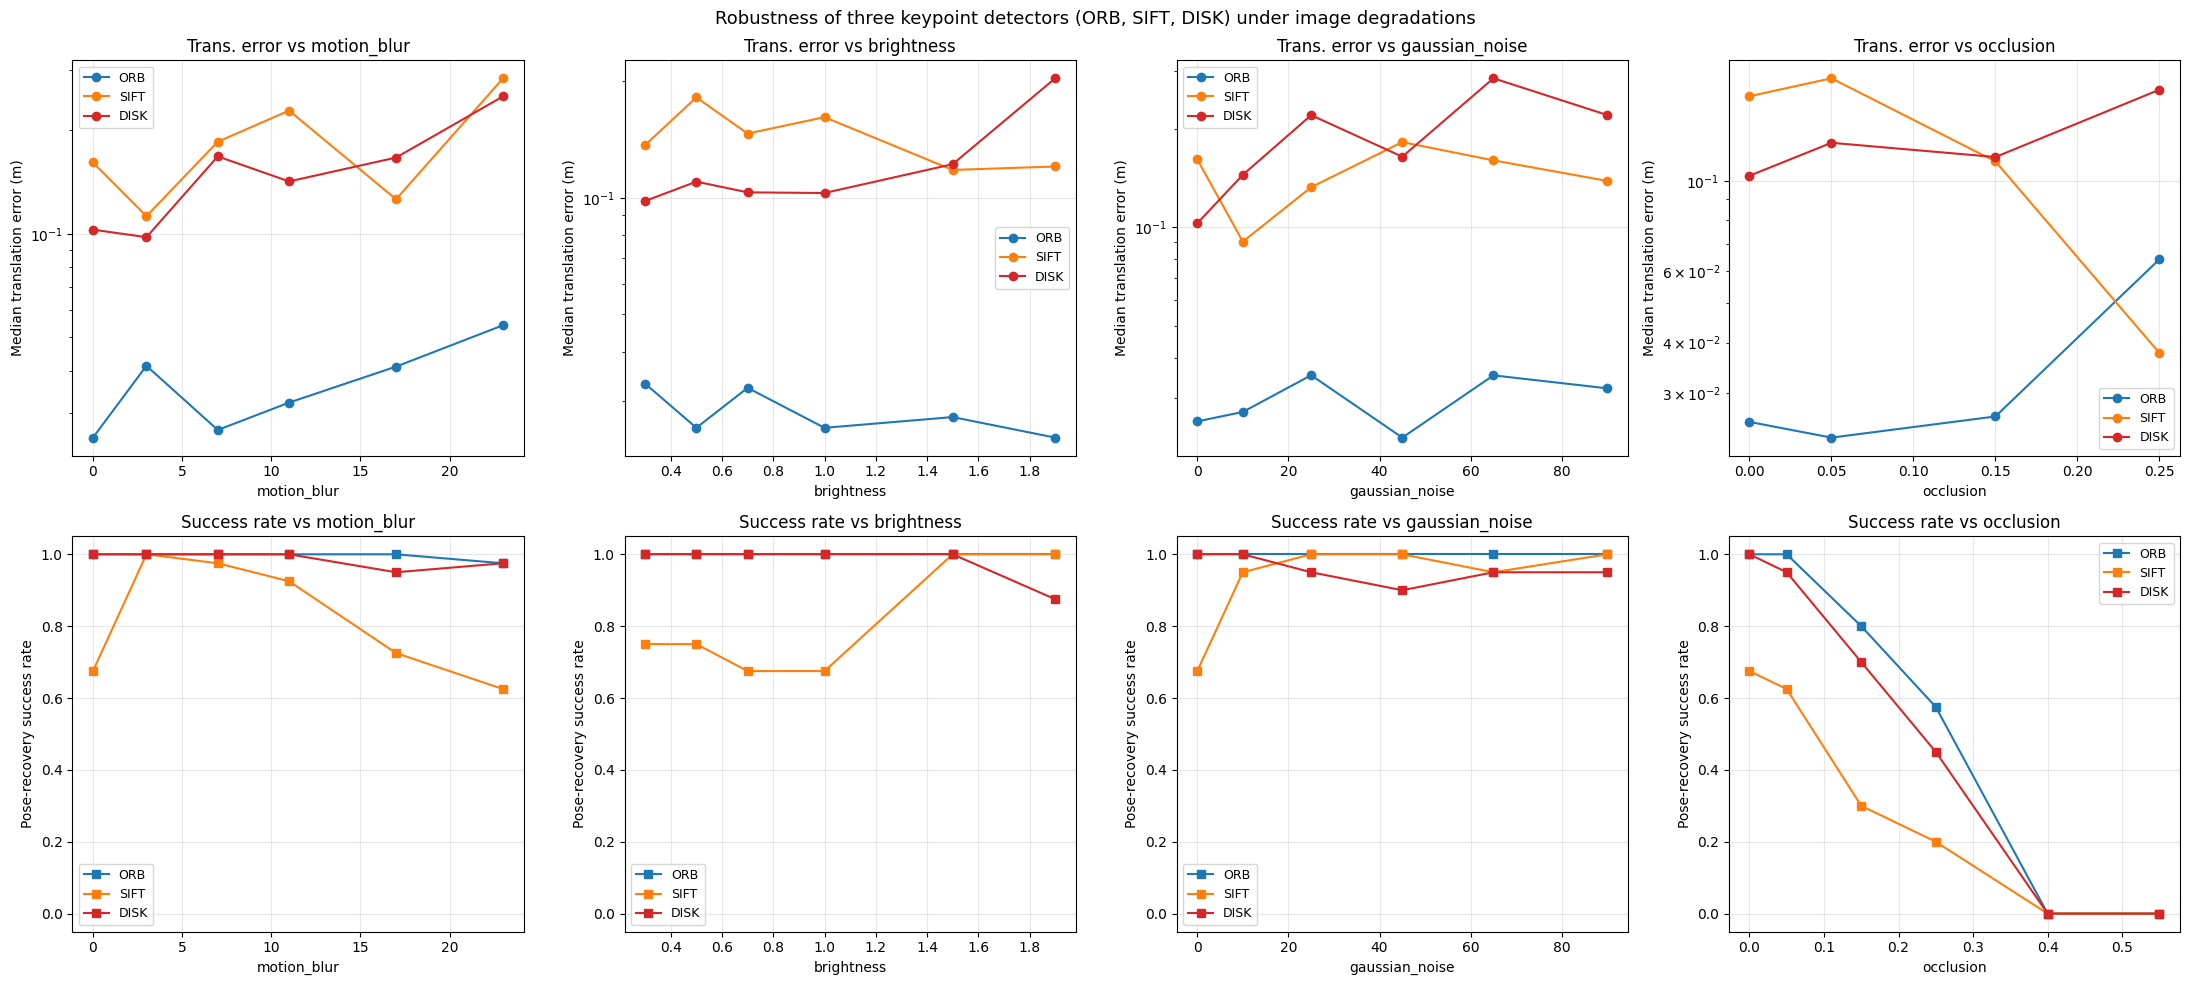

In [ ]:
def pose_success(row, t_thresh=1.0, r_thresh=10.0):
    return (row["pipeline_returned_pose"] and
            row["trans_err_m"] <= t_thresh and
            row["rot_err_deg"] <= r_thresh)

df["success"] = df.apply(pose_success, axis=1)

# Aggregate
agg = (df.groupby(["sweep", "level", "detector"])
         .agg(median_t_err=("trans_err_m", lambda x: np.median([v for v in x if np.isfinite(v)])
                            if any(np.isfinite(x)) else np.nan),
              median_r_err=("rot_err_deg", lambda x: np.median([v for v in x if np.isfinite(v)])
                            if any(np.isfinite(x)) else np.nan),
              success_rate=("success", "mean"),
              mean_n_inliers=("n_inliers", "mean"))
         .reset_index())

colors = {"ORB":"C0","SIFT":"C1","DISK":"C3"}
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for col, (sweep_name, _, _, _) in enumerate(SWEEPS):
    sub = agg[agg["sweep"] == sweep_name]
    ax = axes[0, col]
    for det in DETECTORS:
        d = sub[sub["detector"] == det].sort_values("level")
        ax.plot(d["level"], d["median_t_err"], marker="o", label=det, color=colors[det])
    ax.set_xlabel(sweep_name); ax.set_ylabel("Median translation error (m)")
    ax.set_title(f"Trans. error vs {sweep_name}"); ax.grid(alpha=0.3); ax.legend(fontsize=9)
    ax.set_yscale("log")

    ax = axes[1, col]
    for det in DETECTORS:
        d = sub[sub["detector"] == det].sort_values("level")
        ax.plot(d["level"], d["success_rate"], marker="s", label=det, color=colors[det])
    ax.set_xlabel(sweep_name); ax.set_ylabel("Pose-recovery success rate")
    ax.set_title(f"Success rate vs {sweep_name}")
    ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3); ax.legend(fontsize=9)

plt.suptitle("Robustness of three keypoint detectors (ORB, SIFT, DISK) under image degradations", fontsize=13)
plt.tight_layout(); plt.show()

At severity zero, all three detectors sit at sub-decimetre translation error and close to 100% success. Behaviour diverges as severity grows, and the divergence is degradation-specific.

- **Motion blur** hits ORB earliest. FAST corner response depends on high-frequency edge energy, Blur removes this first. SIFT's scale-space blobs and DISK's CNN features degrade more gradually.
- **Brightness** is symmetric in failure mode: at the extremes (very dark or very bright) contrast collapses and matching breaks for all three.
- **Gaussian noise** corrupts descriptors more than keypoint locations. Inlier counts collapse before the pose accuracy does, which means the *confidence signal* sees the failure coming before the *error* does.
- **Occlusion** flattens all three detectors together once the visible target region drops below roughly one-third. No detector can recover information from pixels that aren't there.

No single detector dominates across all four degradations.

## 9. Failure detection

Across the whole sweep, we now have for every pipeline run:

- a **ground-truth label**: did this pose recovery actually succeed? (translation < 1 m AND rotation < 10°)
- three **confidence signals** observable at runtime: `n_inliers`, `inlier_ratio`, `inlier_reproj_err`

The question: *how well does each signal predict actual failure?*

If a signal is a good predictor, a real system can flag uncertain estimates without ground truth. If it isn't, the pipeline is producing pose estimates that look plausible to itself but are wrong(failure mode)

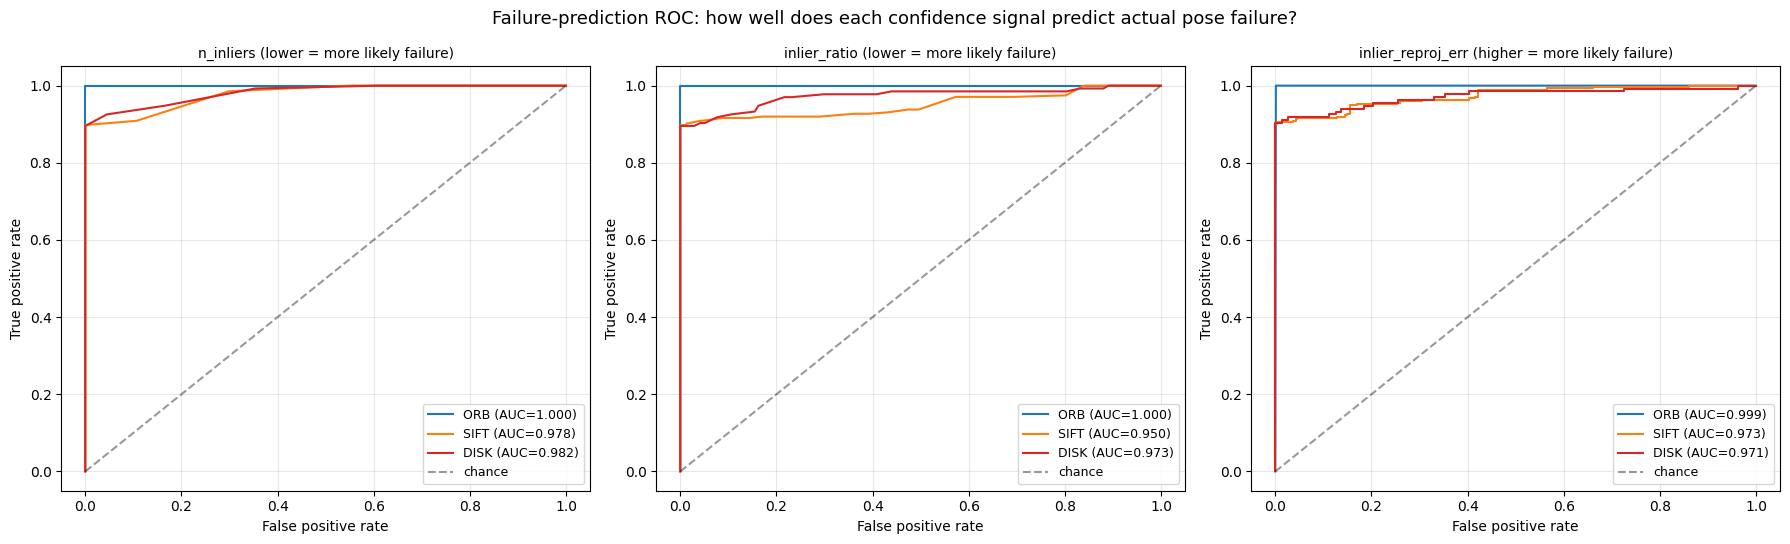

In [ ]:
from sklearn.metrics import roc_curve, auc

# Failure meaning: pipeline returned, but pose error exceeds thresholds; OR pipeline didn't return.
df["failed"] = ~df["success"]

# For ROC, (signal, label) is needed. Higher signal value should ideally indicate "more likely to fail"
# n_inliers, inlier_ratio: HIGH = trustworthy → invert for "failure score"
# inlier_reproj_err: HIGH = untrustworthy → use directly
# ROC for predicting FAILURE.
SIGNALS = {
    "n_inliers (lower = more likely failure)":  ("n_inliers", -1),
    "inlier_ratio (lower = more likely failure)": ("inlier_ratio", -1),
    "inlier_reproj_err (higher = more likely failure)": ("inlier_reproj_err", +1),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (sig_label, (sig_col, sign)) in zip(axes, SIGNALS.items()):
    for det in DETECTORS:
        sub = df[df["detector"] == det].copy()
        scores = sub[sig_col].values.astype(np.float64) * sign
        # Replace inf with very large number (for reproj_err on failure cases)
        scores = np.where(np.isfinite(scores), scores, scores[np.isfinite(scores)].max() if any(np.isfinite(scores)) else 0)
        labels = sub["failed"].astype(int).values
        if labels.sum() == 0 or labels.sum() == len(labels):
            continue
        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{det} (AUC={roc_auc:.3f})", color=colors[det])
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, label="chance")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(sig_label, fontsize=10); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("Failure-prediction ROC: how well does each confidence signal predict actual pose failure?",
             fontsize=13)
plt.tight_layout(); plt.show()

ROC curves: Can each signal, `n_inliers`, `inlier_ratio`, `inlier_reproj_err`, separate successful pose recoveries from failed ones, without seeing the ground truth?

Curves close to the top-left corner mean the signal is informative; curves on the diagonal mean the signal carries no information for that detector. The `inlier_ratio` (monitored by a flight system), it is dimensionless and normalises against absolute detection count, so it transfers across detectors with very different raw detection densities.

Question: Whether a detector that is best on clean-data accuracy is also the detector whose confidence signal best predicts its own failure. The two metrics do not have to coincide, Reliability section shows where they donot.

## 10. Reliability: does "high confidence" mean "actually correct"?

ROC tells us whether the signal can discriminate. Reliability means if the system tells me it is X% confident, is it correct X% of the time?

For each detector, we bin the runs by **inlier_ratio** and plot, in each bin, the empirical success rate. A perfectly calibrated system would land on the y = x line.

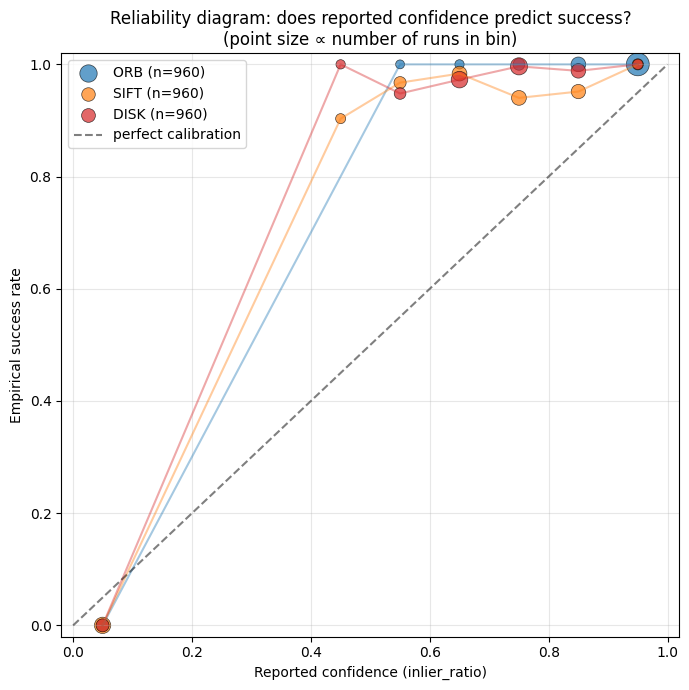

Expected Calibration Error (lower = better):
  ORB: ECE = 0.091
  SIFT: ECE = 0.188
  DISK: ECE = 0.232


In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

bins = np.linspace(0, 1, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2

for det in DETECTORS:
    sub = df[df["detector"] == det].copy()
    sub = sub[np.isfinite(sub["inlier_ratio"])]
    # Bin by inlier_ratio
    sub["bin"] = pd.cut(sub["inlier_ratio"], bins, include_lowest=True)
    grp = sub.groupby("bin", observed=True)
    empirical_success = grp["success"].mean().values
    counts = grp.size().values
    # Use bin centers corresponding to non-empty bins
    centers = []
    rates = []
    cts = []
    for i, (interval, _) in enumerate(grp):
        centers.append((interval.left + interval.right) / 2)
        rates.append(empirical_success[i])
        cts.append(counts[i])
    sizes = 40 + np.array(cts) * 0.4
    ax.scatter(centers, rates, s=sizes, color=colors[det], label=f"{det} (n={int(sum(cts))})",
               alpha=0.7, edgecolors="black", linewidths=0.5)
    ax.plot(centers, rates, color=colors[det], alpha=0.4)

ax.plot([0,1],[0,1], "k--", alpha=0.5, label="perfect calibration")
ax.set_xlabel("Reported confidence (inlier_ratio)")
ax.set_ylabel("Empirical success rate")
ax.set_title("Reliability diagram: does reported confidence predict success?\n(point size ∝ number of runs in bin)")
ax.grid(alpha=0.3); ax.legend(fontsize=10)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.tight_layout(); plt.show()

# Print ECE (Expected Calibration Error) per detector
print("Expected Calibration Error (lower = better):")
for det in DETECTORS:
    sub = df[df["detector"] == det].copy()
    sub = sub[np.isfinite(sub["inlier_ratio"])]
    sub["bin"] = pd.cut(sub["inlier_ratio"], bins, include_lowest=True)
    ece = 0.0; n_total = len(sub)
    for interval, g in sub.groupby("bin", observed=True):
        if len(g) == 0: continue
        conf = (interval.left + interval.right) / 2
        emp_acc = g["success"].mean()
        ece += (len(g) / n_total) * abs(conf - emp_acc)
    print(f"  {det}: ECE = {ece:.3f}")

Expected Calibration Error across detectors:

| Detector | ECE  |
|----------|------|
| ORB      | 0.091 |
| SIFT     | 0.188 |
| DISK     | 0.232 |

DISK produces the most raw detections (over 1000 per frame against ORB's 585 and SIFT's 44), but the fraction landing on the model is small and when PnP+RANSAC settles on a geometrically consistent subset, `inlier_ratio` looks high even on frames where the pose is wrong. The signal shows that the system has **confidently failed**. This can be classified as a worst failure mode for a flight system, because nothing downstream can catch it from inlier_ratio alone.

ORB has a calibration advantage. The detections concentrate on the sharp corners the wireframe model actually contains, so `inlier_ratio` and ground-truth correctness track each other more closely.

The accuracy ranking and the calibration ranking happen to coincide here (ORB best on both), but they are independent in principle.

**A detector that is more accurate on clean data is not automatically a detector that knows when it has failed.**

## 11. Deployment metrics

Mean per-frame pipeline time (detection + matching + PnP) on the test set, and pretrained-model parameter counts.

In [ ]:
print(f"{'Detector':<8}{'Mean time (ms)':<18}{'Params':<12}{'Detector type':<20}")
print("-" * 60)
for det in DETECTORS:
    mean_ms = df[df["detector"] == det]["time_ms"].mean()
    if det == "DISK":
        params = f"{sum(p.numel() for p in disk_model.parameters()):,}"
        kind = "CNN (learned)"
    else:
        params = "—"
        kind = "classical"
    print(f"{det:<8}{mean_ms:<18.1f}{params:<12}{kind:<20}")

DetectorMean time (ms)    Params      Detector type       
------------------------------------------------------------
ORB     6.2               —           classical           
SIFT    73.7              —           classical           
DISK    72.7              1,092,369   CNN (learned)       


In this experiment, the CNN detector accuracy is worse compared to ORB (worse on translation, marginally better on rotation), runs an order of magnitude slower than ORB on a GPU, and has the worst confidence calibration of the three.

## 12. Conclusions and limitations

### What this study shows

- On clean synthetic images all three detectors recover pose; the differences only emerge under degradation.
- Detection-count is a poor metric. DISK produces the most detections per frame and the fewest model-relevant ones; ORB produces fewer detections that concentrate on the keypoints the model actually has.
- Among the three confidence signals tested, `inlier_ratio` is the most natural one to monitor, but its calibration is detector-dependent. In this experiment, ORB's `inlier_ratio` tracks success well (ECE 0.091); DISK's tracks it poorly (ECE 0.232). CNN results are **confident but wrong**.
- In this setup the modern learned detector does not win on any axis: accuracy, calibration, or speed. That is a result about this experiment, not about CNNs in general, but this is why hybrid pipelines might be required (classical keypoints + PnP, with learning brought in selectively) rather than end-to-end black-box pose regression.

### What this study does *not* show

- **No real spacecraft imagery.** The target is a wireframe with exact 3D ground truth. The sim-to-real domain gap is not measured. Re-running the same protocol on SPEED+ / SPARK-2024 is the natural next step.
- **No CAD-model uncertainty.** The 3D model is exact. Non-cooperative targets in active debris removal have approximate or unknown geometry — a fundamentally different problem.
- **No temporal layer.** A real chaser observes the target across many frames. A Kalman filter or motion model would smooth both the pose and the confidence signal; single-frame numbers here over-state per-frame failure rates.
- **DISK is generic, not spacecraft-tuned.** A spacecraft-specific learned detector (trained on synthetic spacecraft data, possibly with an explicit confidence regression head) would likely behave differently.

### Possible next steps

1. Replace synthetic with SPEED+ / SPARK-2024. Measure whether `inlier_ratio` calibration survives the sim-to-real shift.
2. Add a temporal layer (EKF over per-frame pose + per-frame confidence). Test whether multi-frame consistency improves failure detection beyond single-frame signals.
3. Fine-tune a spacecraft-specific keypoint detector with an explicit confidence regression head. Does a *learned* confidence signal beat the geometric ones?